# Minimal model comparison between versions of DNM-CNM hybrid models and a DNM-DDM hybrid model
**In this comparison I am using a new subjective h estimation**

This notebook follows a simplified version of the modeling framework from Prof. Musslick's cognitive modeling lecture (winter semester 2024).
The following list represents some of the best practices one should follow in modelling that are neglected in this branch:
1. Before deciding on a modeling approach one should decide which questions the modeling process is supposed to help answer.
2. Before fitting the models to participant data, one should generate synthetic data from the models based on different given "true" parameters. Then one should check how well these paramaters can be recovered by fitting the models to the synthetic data and comparing the true to the fitted parameters. Then one should fit each model to data generated by the other models and by itself, to validate model recovery.
3. After fitting the models to generated data and before reporting the results one should validate the models by exploring in detail which parts of the experimental data they can and cannot explain.



## Step 0: Setup and imports

In [37]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

# Resolve repository root from either repo root or src/elias working directories.
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'src').exists() and (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
# Handle case where we're in src/elias/... - go up to Glaze root
while REPO_ROOT.name == 'elias' or (REPO_ROOT.parent / 'src' / 'elias').exists():
    if (REPO_ROOT / 'src' / 'elias').exists():
        break
    REPO_ROOT = REPO_ROOT.parent

# Ensure both top-level src and src/elias are importable for notebook execution.
SRC_ROOT = REPO_ROOT / 'src'
ELIAS_SRC = SRC_ROOT / 'elias'
for import_path in (SRC_ROOT, ELIAS_SRC):
    if str(import_path) not in sys.path:
        sys.path.insert(0, str(import_path))

from elias_models import fit_models_train_split, score_models_test_split
from elias_models.data_pipeline import (
    attach_subjective_h_from_train,
    build_normative_belief_columns,
    fit_blockwise_subjective_h_choice_only,
    load_participant_data,
    preprocess_loaded_participant_data,
)

DATA_CSV_PATH = REPO_ROOT / 'data' / 'participants.csv'
print(f'REPO_ROOT = {REPO_ROOT}')
print(f'DATA_CSV_PATH = {DATA_CSV_PATH}')

REPO_ROOT = /home/elias/Documents/Studium/coxiMaster/2025_WS/ChangingENVS/GlazeGroupRepo/Glaze
DATA_CSV_PATH = /home/elias/Documents/Studium/coxiMaster/2025_WS/ChangingENVS/GlazeGroupRepo/Glaze/data/participants.csv


## Step 1: Load and preprocess data

In [38]:
# Load raw participant rows and normalize choice coding.
df_loaded = load_participant_data(csv_path=str(DATA_CSV_PATH))

# Apply filtering and TRAIN/TEST split assignment using existing policy.
preprocessing_output = preprocess_loaded_participant_data(df_loaded)
df_preprocessed = preprocessing_output['df_all'].copy()

print(f'Rows loaded: {len(df_loaded)}')
print(f'Rows after preprocessing: {len(df_preprocessed)}')
print(f"Rows removed: {preprocessing_output['removed_n']}")

# Show participant/block structure after exclusions.
display(preprocessing_output['participant_structure_table'])

# Show reasons for trial removals.
removed_rows_df = preprocessing_output['removed_rows_df'].copy()
if removed_rows_df.empty:
    print('No rows removed during preprocessing.')
else:
    removal_reasons = pd.DataFrame(
        [
            {
                'reason': 'invalid required numeric fields',
                'n_trials': int(removed_rows_df['removed_invalid_required'].sum()),
            },
            {
                'reason': 'reaction_time_ms outside [150, 5000]',
                'n_trials': int(removed_rows_df['removed_rt_out_of_range'].sum()),
            },
            {
                'reason': 'overlap (both reasons on same row)',
                'n_trials': int(
                    (
                        (removed_rows_df['removed_invalid_required'] == 1)
                        & (removed_rows_df['removed_rt_out_of_range'] == 1)
                    ).sum()
                ),
            },
        ]
    )
    print('Removal reasons (row-level):')
    display(removal_reasons)

    removal_by_participant = (
        removed_rows_df.groupby('participant_id', as_index=False)
        .agg(
            n_removed=('trial_index', 'size'),
            n_invalid_required=('removed_invalid_required', 'sum'),
            n_rt_out_of_range=('removed_rt_out_of_range', 'sum'),
        )
        .sort_values('n_removed', ascending=False)
        .reset_index(drop=True)
    )
    print('Removal counts by participant:')
    display(removal_by_participant)

Rows loaded: 467
Rows after preprocessing: 456
Rows removed: 11


,participant_id,n_blocks_before,n_blocks_after,all_blocks_nominal_before,has_expected_blocks_before,has_expected_blocks_after
0,P01,4,4,True,True,True
1,P02,4,4,False,True,True
2,P03,4,4,True,True,True


Removal reasons (row-level):


,reason,n_trials
0,invalid required numeric fields,0
1,"reaction_time_ms outside [150, 5000]",11
2,overlap (both reasons on same row),0


Removal counts by participant:


,participant_id,n_removed,n_invalid_required,n_rt_out_of_range
0,P01,11,0,11


OVERSIGHT: Here we excluded all trials that where outside of the range from 150 to 5000 ms. But In step 3 we use 6000 ms as the upper bound for modeling reaction times.

### Step 1 Explanation

In this step I load the raw participant rows, standardize the choice coding, apply preprocessing filters, and create the TRAIN/TEST split.

I use `participant_structure_table` as a quick sanity check:
- `n_blocks_before`: how many blocks were found before exclusions.
- `n_blocks_after`: how many blocks still have rows after exclusions.
- `all_blocks_nominal_before`: `True` only if every block had the nominal pre-exclusion trial count (`40` by default).
- `has_expected_blocks_before` / `has_expected_blocks_after`: whether the participant has the expected number of blocks (`4` by default) before/after exclusions.

This table helps me confirm that preprocessing did not break the block structure before moving to Step 2.



## Step 2: Fit subjective hazard and build normative state

In [39]:
# Fit one subjective hazard per participant-block from TRAIN choices only.
subjective_h_table = fit_blockwise_subjective_h_choice_only(df_preprocessed, beta=1.0)

# Attach those fitted hazard values to all rows for each participant-block.
df_with_h = attach_subjective_h_from_train(df_preprocessed, subjective_h_table)

# Rebuild prior and posterior normative belief columns used by all models.
df_model = build_normative_belief_columns(df_with_h)

print('Subjective-H fits (participant-block):')
display(subjective_h_table)

print('Modeling frame preview:')
display(df_model[['participant_id', 'block_id', 'trial_index', 'split', 'H', 'prev_normative_belief_L', 'normative_belief_L']].head())

Subjective-H fits (participant-block):


,participant_id,block_id,n_train_trials,fitted_subjective_h,fit_choice_nll,fit_choice_nll_per_trial,beta_fixed,h_grid_start,h_grid_end,h_grid_step
0,P01,1,23,0.171,2.288515,0.099501,1.0,0.001,0.999,0.01
1,P01,2,30,0.021,3.717881,0.123929,1.0,0.001,0.999,0.01
2,P01,3,28,0.091,8.233057,0.294038,1.0,0.001,0.999,0.01
3,P01,4,30,0.281,4.726424,0.157547,1.0,0.001,0.999,0.01
4,P02,1,17,0.111,0.128052,0.007532,1.0,0.001,0.999,0.01
5,P02,2,30,0.441,0.336754,0.011225,1.0,0.001,0.999,0.01
6,P02,3,30,0.281,0.325924,0.010864,1.0,0.001,0.999,0.01
7,P02,4,30,0.091,0.025527,0.000851,1.0,0.001,0.999,0.01
8,P03,1,30,0.011,6.377562,0.212585,1.0,0.001,0.999,0.01
9,P03,2,30,0.511,9.990634,0.333021,1.0,0.001,0.999,0.01


Modeling frame preview:


,participant_id,block_id,trial_index,split,H,prev_normative_belief_L,normative_belief_L
0,P01,1,1,TRAIN,0.171,0.000000,3.226995
1,P01,1,3,TRAIN,0.171,3.226995,3.328248
2,P01,1,4,TRAIN,0.171,3.328248,2.950662
3,P01,1,5,TRAIN,0.171,2.950662,3.281213
4,P01,1,6,TRAIN,0.171,3.281213,6.772859


### How to read the modeling frame preview

The preview shows:
`participant_id`, `block_id`, `trial_index`, `split`, `H`, `prev_normative_belief_L`, `normative_belief_L`.

Columns after `trial_index`:
- `split`: TRAIN/TEST assignment.
- `H`: fitted subjective hazard for that participant-block.
- `prev_normative_belief_L`: prior log-odds before current evidence.
- `normative_belief_L`: posterior log-odds after adding current trial evidence (`LLR`).

So `prev_normative_belief_L` is start-of-trial state, and `normative_belief_L` is end-of-trial state.

### Step 2 Explanation

Step 2 has two goals:
1. Fit one subjective hazard value `H` per participant-block.
2. Rebuild the belief-state columns (`prev_normative_belief_L`, `normative_belief_L`) from that fitted `H`.

#### New subjective-`H` Implementation

In the original triangles app, subjective `H` was refit as a running snapshot after each trial, using all block data available so far. That is useful for interactive feedback, but it is noisy for model comparison.

In this workflow I fit one fixed `H` per participant-block from TRAIN only, then carry that `H` into both TRAIN and TEST rows of that block.

I do this because it:
- avoids TEST leakage into model construction,
- reduces trial-to-trial noise from instantaneous refits,
- keeps belief recursion consistent within a participant-block,
- and gives a reproducible modeling frame for Step 3 and Step 4.






## Step 3: Fit candidate models on TRAIN


In [40]:
step_3_is_active = False  # Set to True to run model fitting (can be time-consuming)
if step_3_is_active == True:
    # Single-pass fit config for all candidate models.
    import os
    from datetime import datetime
    import pickle

    # Use other parameters for quicker test runs .
    # (These took me 43 mins with 14 workers on 16 CPU machine)
    FIT_CONFIG = {
        'n_starts': 2,  # number of random initializations for the optimizer
        'n_iterations': 3,  # max optimizer steps per start (kept low for speed)
        'n_sims_per_trial': 100,  # Monte Carlo simulations per trial for likelihood estimation
        'fit_objective': 'joint',  # objective to optimize (joint choice+RT)
        'fixed_model_params': {
            'dt_ms': 1,  # simulation time step in milliseconds
            'min_duration_ms': 150.0,  # minimum simulated decision duration
            'max_duration_ms': 6000.0,  # maximum simulated decision duration
        },
    }

    AVAILABLE_CPUS = os.cpu_count() or 1
    SAFE_MAX_WORKERS = max(1, AVAILABLE_CPUS - 1)
    N_JOBS_FIT = max(1, min(14, SAFE_MAX_WORKERS))
    print(f'Step 3 workers: {N_JOBS_FIT} (CPUs detected: {AVAILABLE_CPUS})')

    fit_output = fit_models_train_split(
        df_model,
        fit_config=FIT_CONFIG,
        random_seed=42,
        n_jobs=N_JOBS_FIT,
    )
    fit_table = fit_output['fit_table'].copy()

    save_fit = True  # Save fit results for later use in step 4

    if save_fit == True:

        # Create output directory if it doesn't exist
        output_dir = REPO_ROOT / 'data'/ 'elias'/ '2026_02_18_joint_fit_run'
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Save fit_output dictionary (contains fit_results needed for step 4)
        fit_output_path = output_dir / 'fit_output.pkl'
        with open(fit_output_path, 'wb') as f:
            pickle.dump(fit_output, f)
        
        # Save fit_table as CSV for easy inspection
        fit_table_path = output_dir / 'fit_table.csv'
        fit_table.to_csv(fit_table_path, index=False)
        
        print(f'Saved fit_output to: {fit_output_path}')
        print(f'Saved fit_table to: {fit_table_path}')

    print('TRAIN fit summary:')
    display(fit_table)

### How fitting is done in Step 3

In this step I do a pooled fit on TRAIN rows: all participants and blocks are combined into one TRAIN dataset per model (not separate fits per participant).

What stays participant-specific vs pooled:
- Participant/block-specific from Step 2: `H` is estimated per participant-block and then fixed.
- Pooled in Step 3: free model parameters are estimated once per candidate model using all TRAIN rows together.

Optimization procedure per model:
- Multi-start stochastic search (`n_starts`, `n_iterations`).
- Simulation-based likelihood evaluation on pooled TRAIN data.
- Keep one best parameter set per model.

#### Why Step 3 uses `joint` fitting

I use `fit_objective='joint'` so fitting and evaluation target the same behavioral objective:
- Choice and RT jointly constrain parameter estimates during fitting.
- This improves objective alignment between Step 3 and Step 4.
- The selected parameters are the ones that best trade off choice and RT fit on TRAIN.

#### Which parameters are fit in Step 3

Free parameters by model:
- `cont_threshold`: `thr_b1`, `thr_b2`, `thr_b3`, `thr_b4`, `t0`, `g`
- `cont_asymptote`: `asy_b1`, `asy_b2`, `asy_b3`, `asy_b4`, `t0`, `g`
- `ddm_dnm`: `a`, `t0`, `k_v`, `k_z`

Not fit in Step 3:
- `H` (already fitted in Step 2)
- `fixed_model_params` values (`dt_ms`, `min_duration_ms`, `max_duration_ms`)

In Step 4 I evaluate these fitted parameter sets on held-out TEST rows with joint choice+RT scoring.



## Step 4: Score fitted models on TEST

In [41]:
import pickle
load_fitted_data = True  # Set to True to load previously saved fit results for step 4

if load_fitted_data == True:
    # Load previously saved fit_output from the specified run directory
    output_dir = REPO_ROOT / 'data' / 'elias'/ '2026_02_18_joint_fit_run'
    fit_output_path = output_dir / 'fit_output.pkl'

    with open(fit_output_path, 'rb') as f:
        fit_output = pickle.load(f)

    fit_table = fit_output['fit_table'].copy()

    print(f'Loaded fit_output from: {fit_output_path}')
    print('TRAIN fit summary:')
    display(fit_table)


Loaded fit_output from: /home/elias/Documents/Studium/coxiMaster/2025_WS/ChangingENVS/GlazeGroupRepo/Glaze/data/elias/2026_02_18_joint_fit_run/fit_output.pkl
TRAIN fit summary:


,model_name,fit_objective,best_fit_objective_score,best_joint_score_train,best_choice_only_score_train,best_rt_only_cond_score_train,n_parameters,n_evaluations,fit_seed
0,cont_asymptote,joint,11904.575242,11904.575242,4452.926256,7451.648985,6,8,1042
1,ddm_dnm,joint,12981.683627,12981.683627,3726.021132,9255.662495,4,8,2042
2,cont_threshold,joint,14354.244603,14354.244603,6175.134061,8179.110541,6,8,42


In [42]:
step_4_is_active = False  # Set to True to run model scoring (can be time-consuming)
if step_4_is_active == True:

    # Score fitted model parameters on pooled TEST rows via simulation likelihood.
    import os
    import pickle
    AVAILABLE_CPUS = os.cpu_count() or 1
    SAFE_MAX_WORKERS = max(1, AVAILABLE_CPUS - 1)
    N_JOBS_SCORE = max(1, min(14, SAFE_MAX_WORKERS))
    print(f'Step 4 workers: {N_JOBS_SCORE} (CPUs detected: {AVAILABLE_CPUS})')

    score_output = score_models_test_split(
        df_model,
        fitted_models=fit_output['fit_results'],
        n_sims_per_trial=1000,  # higher precision; slower
        rt_bin_width_ms=10.0,  # finer RT density bins
        rt_max_ms=6000.0,
        eps=1e-12,
        random_seed=10_000,
        n_jobs=N_JOBS_SCORE,
    )
    score_table = score_output['score_table'].copy()

    save_score = True

    if save_score == True:

        # Create output directory if it doesn't exist
        output_dir = REPO_ROOT / 'data'/  'elias'/ '2026_02_18_joint_fit_run'
        output_dir.mkdir(parents=True, exist_ok=True)

        # Save score_output dictionary (contains trial_scores needed for step 5)
        score_output_path = output_dir / 'score_output.pkl'
        with open(score_output_path, 'wb') as f:
            pickle.dump(score_output, f)

        # Save score_table as CSV for easy inspection
        score_table_path = output_dir / 'score_table.csv'
        score_table.to_csv(score_table_path, index=False)

        print(f'Saved score_output to: {score_output_path}')
        print(f'Saved score_table to: {score_table_path}')

    print(f"Held-out winner (lowest TEST joint score): {score_output['winner_model_name']}")
    display(score_table)

### How scoring is done in Step 4

Step 4 is held-out scoring on TEST rows only. I do not refit parameters here.

What is fixed vs evaluated:
- Fixed from Step 3: each model's best fitted parameter set (`fit_output['fit_results']`).
- Evaluated in Step 4: how well those fixed parameters predict unseen TEST behavior.

Scoring procedure per model (pooled TEST rows):
- Simulate trial outcomes (`n_sims_per_trial`).
- Estimate `p_choice`.
- Estimate `p_rt_given_choice`.
- Compute trial terms:
  - `nll_choice = -log(p_choice)`
  - `nll_rt_cond = -log(p_rt_given_choice)`
  - `nll_joint = nll_choice + nll_rt_cond`
- Sum over TEST rows:
  - `choice_only_score_test`
  - `rt_only_cond_score_test`
  - `joint_score_test`

### Why Step 4 uses joint scoring

Step 3 and Step 4 now use aligned joint objectives. I use joint choice+RT in Step 4 to evaluate how well the fitted parameters generalize to unseen behavior.

### How to read the Step 4 output table

- `joint_score_test`: primary ranking metric (lower is better)
- `choice_only_score_test`: choice contribution
- `rt_only_cond_score_test`: RT|choice contribution
- `n_trials_test`: number of TEST trials
- `score_seed`: simulation seed base

The reported winner is the model with the lowest `joint_score_test`.



## Step 5: Summary and Plot

In [43]:
import pickle
load_score_output = True  # Set to True to load previously saved score results for step 5
if load_score_output == True:
    # Load previously saved score_output from the specified run directory
    output_dir = REPO_ROOT / 'data' / 'elias' / '2026_02_18_joint_fit_run'
    score_output_path = output_dir / 'score_output.pkl'

    with open(score_output_path, 'rb') as f:
        score_output = pickle.load(f)

    score_table = score_output['score_table'].copy()

    print(f'Loaded score_output from: {score_output_path}')
    print('TEST score summary:')
    display(score_table)



Loaded score_output from: /home/elias/Documents/Studium/coxiMaster/2025_WS/ChangingENVS/GlazeGroupRepo/Glaze/data/elias/2026_02_18_joint_fit_run/score_output.pkl
TEST score summary:


,model_name,joint_score_test,choice_only_score_test,rt_only_cond_score_test,n_trials_test,score_seed
0,cont_asymptote,4090.206027,1638.764502,2451.441525,118,10000
1,ddm_dnm,4654.363503,1431.805643,3222.557860,118,12000
2,cont_threshold,4963.724677,2195.183551,2768.541127,118,11000


In [44]:
# Step 5 setup: prepare TEST overview tables and define plot functions.
import numpy as np
from elias_models.model_fitting import get_parameter_spec

overview_table = score_table.copy()
overview_table = overview_table.sort_values(['joint_score_test', 'model_name']).reset_index(drop=True)
model_order = overview_table['model_name'].astype(str).tolist()

# Add model complexity and TEST BIC for side-by-side comparison.
param_count_map = {
    model_name: len(get_parameter_spec(model_name))
    for model_name in overview_table['model_name'].astype(str).unique()
}
overview_table['n_parameters'] = overview_table['model_name'].astype(str).map(param_count_map).astype(int)
overview_table['bic_test_joint'] = (
    overview_table['n_parameters'].astype(float) * np.log(overview_table['n_trials_test'].astype(float))
    + 2.0 * overview_table['joint_score_test'].astype(float)
)

# Keep key columns first for readability.
preferred_cols = [
    'model_name',
    'joint_score_test',
    'bic_test_joint',
    'choice_only_score_test',
    'rt_only_cond_score_test',
    'n_trials_test',
    'n_parameters',
    'score_seed',
]
overview_table = overview_table[[col for col in preferred_cols if col in overview_table.columns]]
metric_df = overview_table.set_index('model_name').loc[model_order]

# Long trial-level table for diagnostic plots.
trial_scores_long = pd.concat(score_output['trial_scores_by_model'].values(), ignore_index=True)
trial_scores_long['model_name'] = trial_scores_long['model_name'].astype(str)

print('Compact TEST-only overview:')
display(overview_table)


def plot_step5_primary_decomposition(metric_df):
    # Primary TEST comparison: stacked joint NLL decomposition.
    component_df = metric_df[['choice_only_score_test', 'rt_only_cond_score_test']]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    component_df.plot(
        kind='bar',
        stacked=True,
        color=['#4C78A8', '#F58518'],
        ax=ax,
    )
    ax.set_title('TEST Joint NLL Decomposition by Model (lower total is better)')
    ax.set_xlabel('Model')
    ax.set_ylabel('NLL contribution (TEST)')
    ax.legend(['Choice NLL', 'RT|Choice NLL'])
    plt.tight_layout()
    plt.show()


def plot_step5_trial_distribution(trial_scores_long, model_order):
    # Per-trial joint NLL distribution (outlier-sensitivity check).
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    box_data = [
        trial_scores_long.loc[trial_scores_long['model_name'] == model_name, 'nll_joint'].to_numpy()
        for model_name in model_order
    ]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.boxplot(
        box_data,
        tick_labels=model_order,
        showfliers=True,
        patch_artist=True,
        boxprops={'facecolor': '#DCEAF7', 'edgecolor': '#4C78A8', 'linewidth': 1.2},
        medianprops={'color': '#E45756', 'linewidth': 2.0},
        whiskerprops={'color': '#4C78A8', 'linewidth': 1.2},
        capprops={'color': '#4C78A8', 'linewidth': 1.2},
        flierprops={
            'marker': 'o',
            'markerfacecolor': '#B279A2',
            'markeredgecolor': '#B279A2',
            'markersize': 4,
            'alpha': 0.6,
        },
    )
    ax.set_title('Per-Trial Joint NLL Distribution (TEST)')
    ax.set_xlabel('Model')
    ax.set_ylabel('Per-trial Joint NLL (lower is better)')
    legend_handles = [
        Patch(facecolor='#DCEAF7', edgecolor='#4C78A8', label='Box (IQR: 25th-75th percentile)'),
        Line2D([0], [0], color='#E45756', linewidth=2.0, label='Median'),
        Line2D([0], [0], color='#4C78A8', linewidth=1.2, label='Whiskers (bars)'),
        Line2D(
            [0], [0], marker='o', linestyle='None',
            markerfacecolor='#B279A2', markeredgecolor='#B279A2', markersize=5,
            alpha=0.6, label='Outliers'
        ),
    ]
    ax.legend(handles=legend_handles, title='Boxplot key', loc='lower right')
    plt.tight_layout()
    plt.show()


def plot_step5_participant_consistency(trial_scores_long, model_order):
    # Participant-level consistency across models.
    participant_mean = trial_scores_long.groupby(['participant_id', 'model_name'], as_index=False)['nll_joint'].mean()
    fig, ax = plt.subplots(figsize=(10, 4.5))
    participant_ids = sorted(participant_mean['participant_id'].astype(str).unique())
    cmap = plt.cm.get_cmap('tab10', len(participant_ids))
    for idx, participant_id in enumerate(participant_ids):
        group = participant_mean[participant_mean['participant_id'].astype(str) == participant_id]
        aligned = group.set_index('model_name').reindex(model_order)
        ax.plot(
            model_order,
            aligned['nll_joint'],
            marker='o',
            linewidth=1.2,
            alpha=0.8,
            color=cmap(idx),
            label=f'Participant {participant_id}',
        )
    mean_curve = (
        participant_mean.groupby('model_name', as_index=False)['nll_joint']
        .mean()
        .set_index('model_name')
        .reindex(model_order)['nll_joint']
    )
    ax.plot(model_order, mean_curve, marker='o', linewidth=2.5, color='black', label='Participant mean')
    ax.set_title('Participant-Level Mean Joint NLL (TEST)')
    ax.set_xlabel('Model')
    ax.set_ylabel('Mean per-trial Joint NLL')
    ax.legend()
    plt.tight_layout()
    plt.show()



Compact TEST-only overview:


,model_name,joint_score_test,bic_test_joint,choice_only_score_test,rt_only_cond_score_test,n_trials_test,n_parameters,score_seed
0,cont_asymptote,4090.206027,8209.036161,1638.764502,2451.441525,118,6,10000
1,ddm_dnm,4654.363503,9327.809745,1431.805643,3222.557860,118,4,12000
2,cont_threshold,4963.724677,9956.073462,2195.183551,2768.541127,118,6,11000


In [ ]:
# Step 5: report-ready LaTeX table from overview_table.
report_table = overview_table.copy()

report_cols = [
    'model_name',
    'joint_score_test',
    'bic_test_joint',
    'choice_only_score_test',
    'rt_only_cond_score_test',
    'n_trials_test',
    'n_parameters',
    'score_seed',
]
report_table = report_table[[c for c in report_cols if c in report_table.columns]].copy()

if 'model_name' in report_table.columns:
    model_label_map = {
        'cont_asymptote': 'Continuous Asymptote',
        'cont_threshold': 'Continuous Threshold',
        'ddm_dnm': 'DNM-DDM',
    }
    report_table['model_name'] = report_table['model_name'].astype(str).map(model_label_map).fillna(report_table['model_name'])

report_table = report_table.rename(columns={
    'model_name': 'Model',
    'joint_score_test': 'Joint NLL (TEST)',
    'bic_test_joint': 'BIC (TEST)',
    'choice_only_score_test': 'Choice NLL (TEST)',
    'rt_only_cond_score_test': 'RT|Choice NLL (TEST)',
    'n_trials_test': 'N_TEST',
    'n_parameters': 'k',
    'score_seed': 'Seed',
})

report_table.insert(0, 'Rank', np.arange(1, len(report_table) + 1, dtype=int))

for col in report_table.select_dtypes(include=['float64', 'float32']).columns:
    report_table[col] = report_table[col].astype(float).round(2)

for col in ['N_TEST', 'k', 'Seed']:
    if col in report_table.columns:
        report_table[col] = report_table[col].astype(int)

latex_caption = 'Held-out TEST model comparison (joint-fit run).'
latex_label = 'tab:elias_overview_test'
latex_table = report_table.to_latex(
    index=False,
    escape=True,
    caption=latex_caption,
    label=latex_label,
    column_format='r' + 'l' + 'r' * (len(report_table.columns) - 2),
)

save_dir = REPO_ROOT / 'data' / 'elias' / '2026_02_18_joint_fit_run'
save_dir.mkdir(parents=True, exist_ok=True)
latex_path = save_dir / 'overview_table_report.tex'
latex_path.write_text(latex_table)

print(latex_table)
print(f'Saved report-ready LaTeX table to: {latex_path}')
display(report_table)


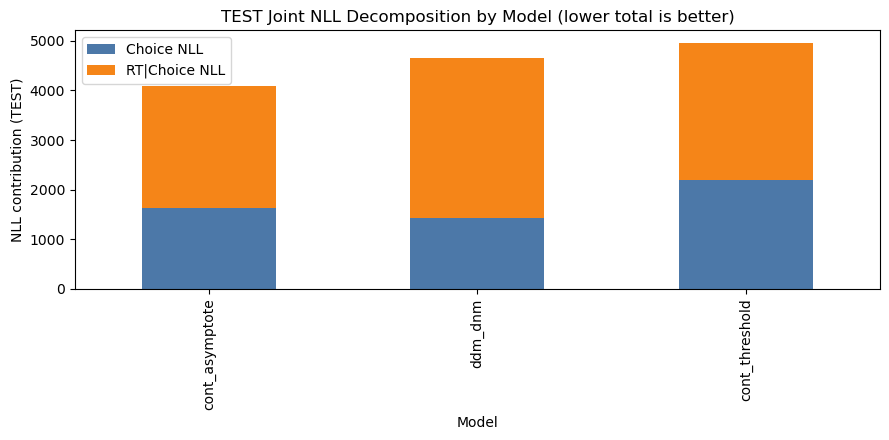

In [45]:
# Step 5 Plot 1
plot_step5_primary_decomposition(metric_df)


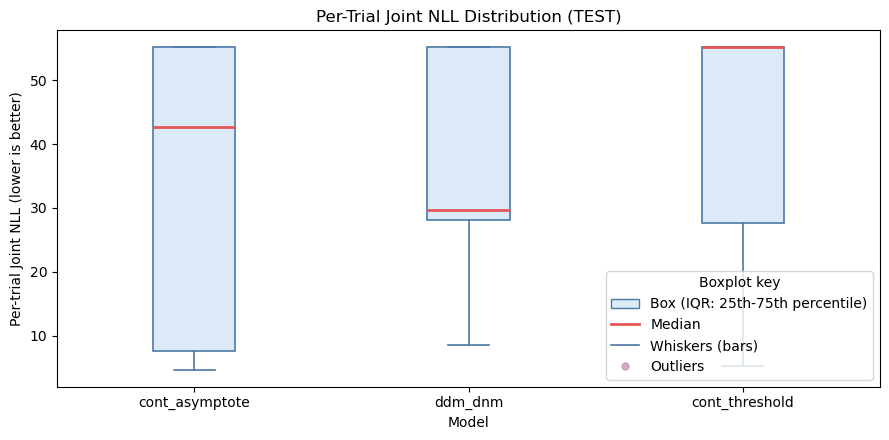

In [46]:
# Step 5 Plot 2
plot_step5_trial_distribution(trial_scores_long, model_order)


Saved combined Step 5 plot to: /home/elias/Documents/Studium/coxiMaster/2025_WS/ChangingENVS/GlazeGroupRepo/Glaze/data/elias/2026_02_18_joint_fit_run/step5_plot1_plot2_combined.png


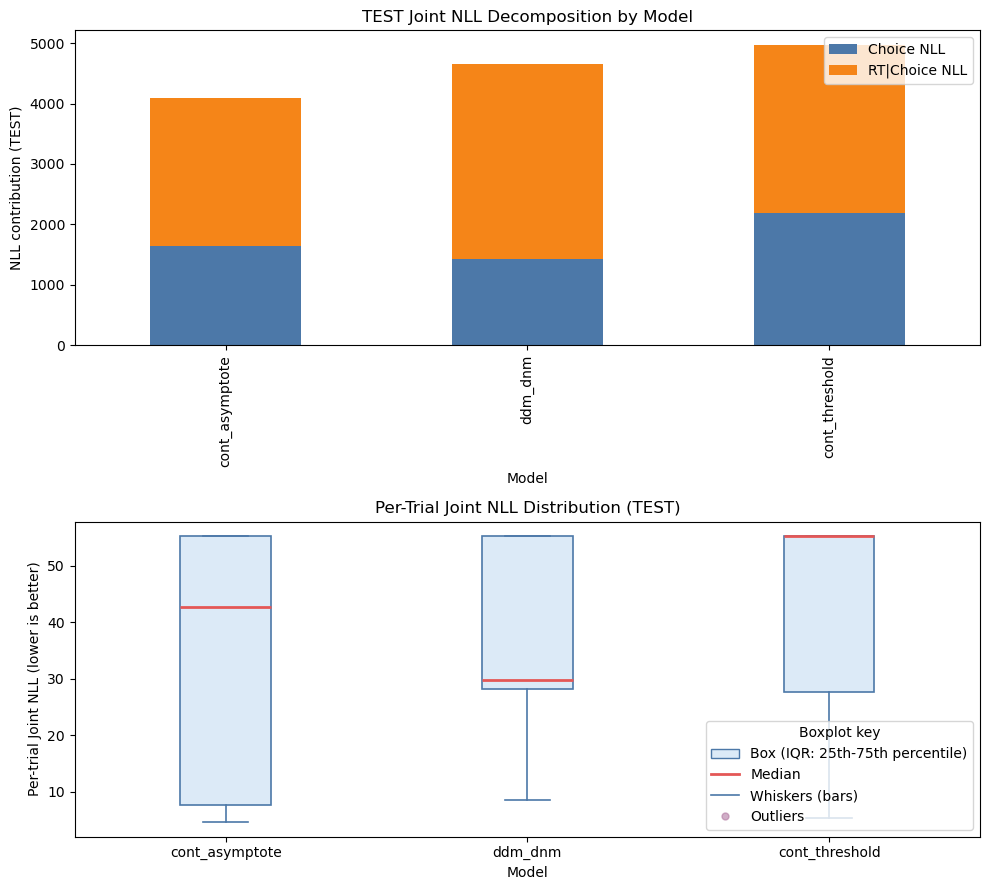

In [51]:
# Step 5 Plot 1+2 in one output, then save as PNG.
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 1, figsize=(10, 9))

# Plot 1: TEST joint-NLL decomposition.
component_df = metric_df[['choice_only_score_test', 'rt_only_cond_score_test']]
component_df.plot(
    kind='bar',
    stacked=True,
    color=['#4C78A8', '#F58518'],
    ax=axes[0],
    legend=False,
)
axes[0].set_title('TEST Joint NLL Decomposition by Model')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('NLL contribution (TEST)')
axes[0].legend(['Choice NLL', 'RT|Choice NLL'], loc='upper right')

# Plot 2: per-trial joint-NLL distribution.
box_data = [
    trial_scores_long.loc[trial_scores_long['model_name'] == model_name, 'nll_joint'].to_numpy()
    for model_name in model_order
]
axes[1].boxplot(
    box_data,
    tick_labels=model_order,
    showfliers=True,
    patch_artist=True,
    boxprops={'facecolor': '#DCEAF7', 'edgecolor': '#4C78A8', 'linewidth': 1.2},
    medianprops={'color': '#E45756', 'linewidth': 2.0},
    whiskerprops={'color': '#4C78A8', 'linewidth': 1.2},
    capprops={'color': '#4C78A8', 'linewidth': 1.2},
    flierprops={
        'marker': 'o',
        'markerfacecolor': '#B279A2',
        'markeredgecolor': '#B279A2',
        'markersize': 4,
        'alpha': 0.6,
    },
)
axes[1].set_title('Per-Trial Joint NLL Distribution (TEST)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Per-trial Joint NLL (lower is better)')
legend_handles = [
    Patch(facecolor='#DCEAF7', edgecolor='#4C78A8', label='Box (IQR: 25th-75th percentile)'),
    Line2D([0], [0], color='#E45756', linewidth=2.0, label='Median'),
    Line2D([0], [0], color='#4C78A8', linewidth=1.2, label='Whiskers (bars)'),
    Line2D(
        [0], [0], marker='o', linestyle='None',
        markerfacecolor='#B279A2', markeredgecolor='#B279A2', markersize=5,
        alpha=0.6, label='Outliers'
    ),
]
axes[1].legend(handles=legend_handles, title='Boxplot key', loc='lower right')

plt.tight_layout()

save_dir = REPO_ROOT / 'data' / 'elias' / '2026_02_18_joint_fit_run'
save_dir.mkdir(parents=True, exist_ok=True)
combined_plot_path = save_dir / 'step5_plot1_plot2_combined.png'
fig.savefig(combined_plot_path, dpi=300, bbox_inches='tight')
print(f'Saved combined Step 5 plot to: {combined_plot_path}')
plt.show()


/tmp/ipykernel_59188/4153484350.py:110: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(participant_ids))


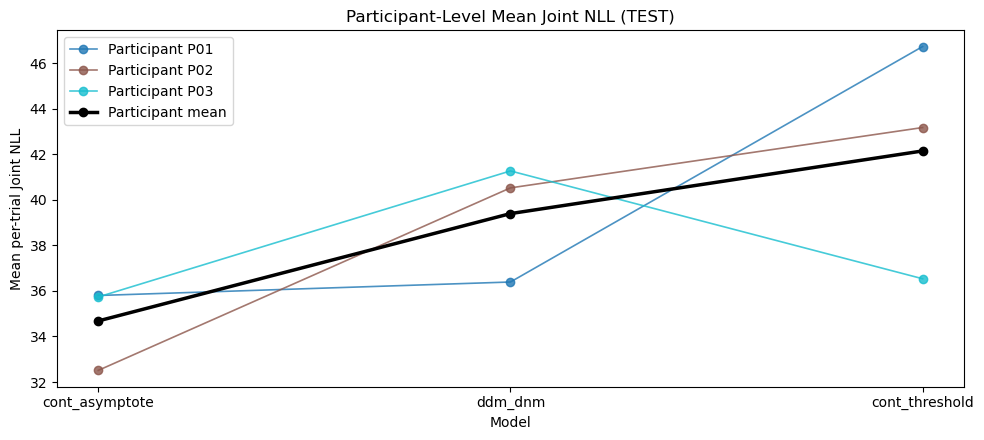

In [48]:
# Step 5 Plot 3
plot_step5_participant_consistency(trial_scores_long, model_order)


## Step 5: Results and Limitations

### Results (current run: `data/elias/2026_02_18_joint_fit_run`)

On held-out TEST rows (`n_trials_test = 118`), the ranking is:
1. `ddm_dnm` (best): `joint_score_test = 4654.36`, `bic_test_joint = 9327.81`
2. `cont_asymptote`: `joint_score_test = 4764.86`, `bic_test_joint = 9558.35`
3. `cont_threshold`: `joint_score_test = 5040.82`, `bic_test_joint = 10110.26`

From the decomposition plot:
- `ddm_dnm` has the lowest total joint error.
- `ddm_dnm` is especially stronger on the choice term.
- `cont_asymptote` is a bit better on RT|choice than `ddm_dnm`, but loses on choice enough to rank lower overall.

From the per-trial and participant-level plots:
- The ranking is not driven by one extreme trial type.
- Participant-level curves mostly support the pooled winner, with different effect sizes across participants.

### Limitations

- Small TEST sample (`118` pooled trials), so differences can be sensitive.
- Pooled evaluation is useful, but it is not a full hierarchical uncertainty analysis.
- No confidence intervals in the final ranking plots.
- Monte Carlo scoring noise remains (depends on simulation settings and seeds).
- Even with aligned joint fitting/scoring, model ranking can still shift with simulation settings and finite-sample variation.
- Conclusions are limited to the tested candidates (`ddm_dnm`, `cont_asymptote`, `cont_threshold`).




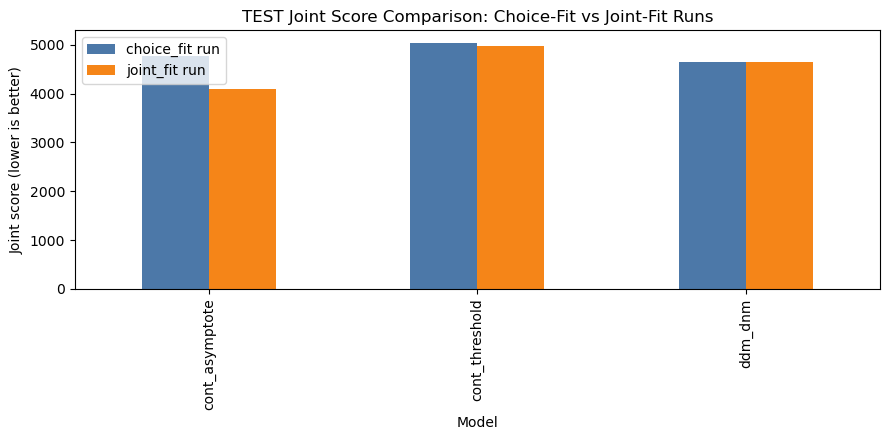

In [49]:
# Comparison plot: choice-fit run vs joint-fit run (TEST joint scores).
from pathlib import Path

choice_run_dir = REPO_ROOT / 'data' / 'elias' / '2026_02_18_choice_fit_run'
joint_run_dir = REPO_ROOT / 'data' / 'elias' / '2026_02_18_joint_fit_run'

choice_score = pd.read_csv(choice_run_dir / 'score_table.csv')
choice_score['run_type'] = 'choice_fit'

joint_score = pd.read_csv(joint_run_dir / 'score_table.csv')
joint_score['run_type'] = 'joint_fit'

compare_df = pd.concat([choice_score, joint_score], ignore_index=True)
model_order_compare = sorted(compare_df['model_name'].astype(str).unique().tolist())

pivot_df = (
    compare_df.pivot(index='model_name', columns='run_type', values='joint_score_test')
    .reindex(model_order_compare)
)

ax = pivot_df.plot(kind='bar', figsize=(9, 4.5), color=['#4C78A8', '#F58518'])
ax.set_title('TEST Joint Score Comparison: Choice-Fit vs Joint-Fit Runs')
ax.set_xlabel('Model')
ax.set_ylabel('Joint score (lower is better)')
ax.legend(['choice_fit run', 'joint_fit run'])
plt.tight_layout()
plt.show()



### Choice-Fit Run

I originally ran `choice_fit` first for robustness and debugging: with this small dataset, fitting only the choice term is more stable and less sensitive to RT-density estimation noise. It gave a clean baseline to verify the pipeline (split logic, parameter search, artifact saving/loading) before introducing joint choice+RT fitting.